Import Dataset from GitHub Repo

In [131]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/tstef87/StefanoCSC672/refs/heads/master/HW2/cybersecurity_intrusion_data.csv'
df = pd.read_csv(url)

Display Data

In [132]:
# Display Data Frame Head
print("\n --- DF Head ---")
print(df.head())

# Display Data Frame Info
print("\n --- DF INFO ---")
df.info()

# Display Summary Statistics
print("\n --- Summary Statistics ---")
display(df.describe())


 --- DF Head ---
  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected  
0         Edge                    0                1  
1      Firefox    

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [133]:
# Look to see if there are any Missing Values in the Data Frame
print("\n--- Missing Values Before Imputation ---")
print(df.isnull().sum())


--- Missing Values Before Imputation ---
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


Find Unique Values

In [134]:
# print the Unique values of the encryption_used Row
print("\n--- Encryption Used Unique Values---")
print(df['encryption_used'].unique())


--- Encryption Used Unique Values---
['DES' 'AES' nan]


In [135]:
from sklearn.impute import SimpleImputer

# Impute Data 
imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
df['encryption_used'] = imputer.fit_transform(df[['encryption_used']]).ravel()

# Look to see if there are any Missing Values in the Data Frame
print("\n--- After Imputation ---")
print(df.isnull().sum())



--- After Imputation ---
session_id             0
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64


Seperate Numeric and Categoric Data

In [137]:
num_data = df.select_dtypes(include=['int64', 'float64'])
cat_data = df.select_dtypes(include=['object'])

print("\n--- Numeric Data ---")
print(num_data)

print("\n--- Categorical Data ---")
print(cat_data)


--- Numeric Data ---
      network_packet_size  login_attempts  session_duration  \
0                     599               4        492.983263   
1                     472               3       1557.996461   
2                     629               3         75.044262   
3                     804               4        601.248835   
4                     453               5        532.540888   
...                   ...             ...               ...   
9532                  194               3        226.049889   
9533                  380               3        182.848475   
9534                  664               5         35.170248   
9535                  406               4         86.664703   
9536                  340               6         86.876744   

      ip_reputation_score  failed_logins  unusual_time_access  attack_detected  
0                0.606818              1                    0                1  
1                0.301569              0                   

In [138]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"), 
    StandardScaler())


cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_data.columns.tolist()),
    ("cat", cat_pipeline, cat_data.columns.tolist()),
])

Heat Map and Correlation Visualization

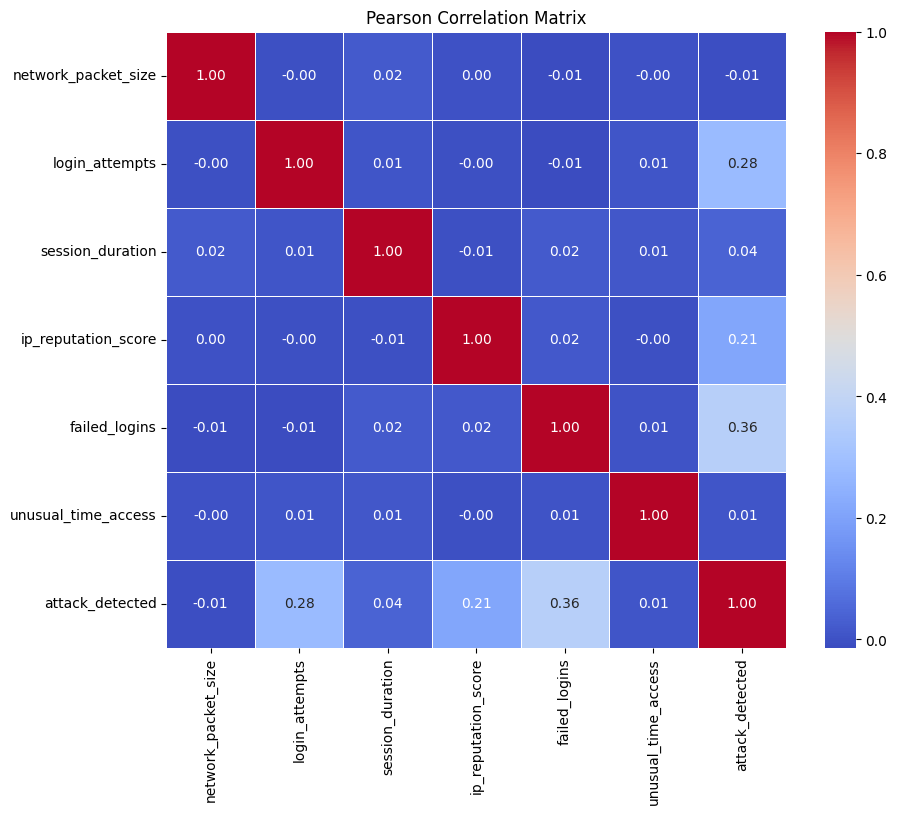

In [139]:
import seaborn as sns

corr_matrix = num_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5)
plt.title('Pearson Correlation Matrix')
plt.show()

Distrubution Charts (Number of Sessions vs Network Packet Size && Number of Sessions vs Log of Network Packet Size)

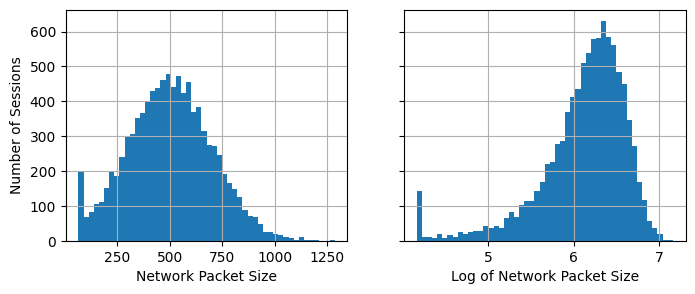

In [141]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
df["network_packet_size"].hist(ax=axs[0], bins=50)
df["network_packet_size"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Network Packet Size")
axs[1].set_xlabel("Log of Network Packet Size")
axs[0].set_ylabel("Number of Sessions")
plt.show()

Scatter plot showing Session Duration and Size of Packet (Blue Dot = No Attack, Red Dot = Attack) 

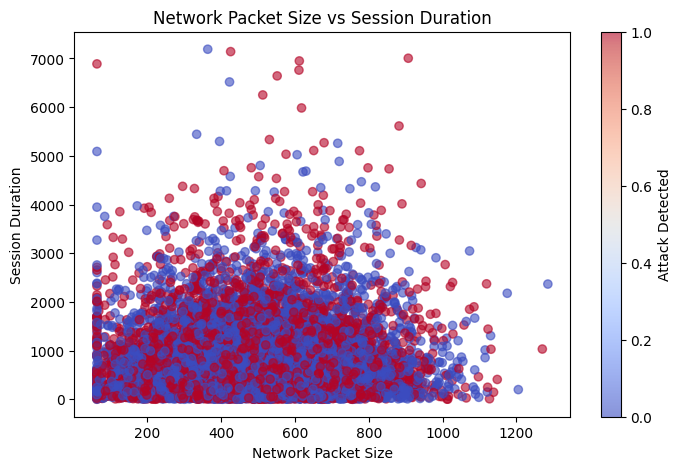

In [142]:
plt.figure(figsize=(8, 5))
plt.scatter(df["network_packet_size"], df["session_duration"],
            c=df["attack_detected"], cmap="coolwarm", alpha=0.6)
plt.xlabel("Network Packet Size")
plt.ylabel("Session Duration")
plt.title("Network Packet Size vs Session Duration")
plt.colorbar(label="Attack Detected")
plt.show()